<a href="https://colab.research.google.com/github/jamie07262/INFO-3608-PROJECT/blob/main/models/KNN_Model_Lite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import os
import re
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss, make_scorer

In [8]:
# GitHub API URL for the directory
api_url = "https://api.github.com/repos/jamie07262/INFO-3608-PROJECT/contents/data/processed"

# Create local directory
os.makedirs("processed", exist_ok=True)

# Get list of files from GitHub API
response = requests.get(api_url)
if response.status_code == 200:
    files = response.json()
    for file in files:
        if file['name'].endswith('.csv'):
            download_url = file['download_url']
            r = requests.get(download_url)
            with open(f"processed/{file['name']}", "wb") as f:
                f.write(r.content)
            print(f"Downloaded: {file['name']}")
else:
    print(f"Failed to access API: {response.status_code}")

print("All CSV files downloaded.")

Downloaded: Features.csv
Downloaded: NewFeaturesForPredictions.csv
Downloaded: Predictions.csv
Downloaded: SampleSubmissionStage2.csv
All CSV files downloaded.


In [9]:
# Load the features file
df_features = pd.read_csv("processed/NewFeaturesForPredictions.csv")
display(df_features)

,Season,T1TeamID,T2TeamID,T1AverageScore,T2AverageScore,PointDifference,T1Seed,T2Seed,SeedDifference,T1Rating,...,T2AverageOpponentFTM,T2AverageOpponentFTA,T2AverageOpponentOR,T2AverageOpponentDR,T2AverageOpponentAst,T2AverageOpponentTO,T2AverageOpponentStl,T2AverageOpponentBlk,T2AverageOpponentPF,T2AveragePointDifference
0,2003,1421,1411,69.615326,72.533333,7.111111,16,16,0,1004.511285,...,11.914815,18.655556,11.881481,22.781481,13.718519,14.259259,7.977778,2.596296,21.533333,1.948148
1,2003,1112,1436,84.511905,67.255172,29.000000,1,16,15,1428.100063,...,10.331034,15.482759,9.517241,21.641379,13.158621,12.910345,7.082759,3.655172,17.772414,4.689655
2,2003,1113,1272,75.344828,74.210728,13.000000,10,7,-3,1169.181611,...,13.333333,20.659004,12.295019,23.482759,13.237548,15.019157,7.252874,3.153257,19.827586,8.693487
3,2003,1141,1166,79.344828,79.006734,6.000000,11,6,-5,1358.162841,...,11.643098,16.619529,11.020202,21.289562,12.329966,17.006734,6.306397,2.569024,19.323232,14.898990
4,2003,1143,1301,73.636015,72.122222,1.777778,8,9,1,1174.931676,...,15.374074,21.129630,10.514815,21.348148,12.511111,14.581481,7.418519,2.811111,19.262963,4.370370
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4547,2024,3425,3163,74.064516,79.878788,-7.000000,1,3,2,1580.223718,...,8.666667,12.242424,7.484848,19.636364,11.757576,15.969697,5.212121,2.181818,16.303030,22.909091
4548,2024,3261,3234,86.696970,92.222222,-7.000000,3,1,-2,1528.433042,...,11.050505,14.841751,8.740741,21.531987,14.087542,14.333333,7.010101,2.811448,19.114478,20.949495
4549,2024,3163,3234,79.878788,92.222222,-2.000000,3,1,-2,1565.718559,...,11.050505,14.841751,8.740741,21.531987,14.087542,14.333333,7.010101,2.811448,19.114478,20.949495
4550,2024,3301,3376,72.979798,86.062500,-19.000000,3,1,-2,1425.117552,...,9.593750,14.031250,9.250000,19.281250,10.062500,14.812500,6.625000,3.125000,16.812500,29.750000


In [11]:
FEATURES = [
    "Divison", "T1Seed", "T2Seed", "SeedDifference",
    "T1AverageScore", "T1AverageFGA", "T1AverageOR", "T1AverageDR",
    "T1AverageBlk", "T1AveragePF", "T1AverageOpponentFGA",
    "T1AverageOpponentBlk", "T1AverageOpponentPF",
    "T1AveragePointDifference",
    "T2AverageScore", "T2AverageFGA", "T2AverageOR", "T2AverageDR",
    "T2AverageBlk", "T2AveragePF", "T2AverageOpponentFGA",
    "T2AverageOpponentBlk", "T2AverageOpponentPF",
    "T2AveragePointDifference",
    "T1Rating", "T2Rating", "RatingDifference",
    "T1Grade", "T2Grade"
]
TARGET = "Win"

X = df_features[FEATURES]
y = df_features[TARGET]
groups = df_features["Season"]
seasons = np.unique(groups)

#Setup cross‐validation and model pipeline
gkf = GroupKFold(n_splits = len(seasons))

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'knn__n_neighbors': list(range(50, 200, 1)),
    'knn__weights': ['uniform', 'distance']
}

#CV loop: inner GridSearchCV (neg_brier_score), outer hold‐out by season
cv_results = []
best_models = []

for season_idx, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    holdout_season = seasons[season_idx]
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    groups_train = groups.iloc[train_idx]

    #Inner CV optimizing on Brier score
    inner_cv = GroupKFold(n_splits = len(np.unique(groups_train)))
    grid = GridSearchCV(
        estimator = pipeline,
        param_grid = param_grid,
        scoring = 'neg_brier_score',
        cv = inner_cv,
        n_jobs = -1
    )
    grid.fit(X_train, y_train, groups = groups_train)
    best = grid.best_estimator_
    best_models.append(best)

    #Evaluate on holdout season
    y_prob = best.predict_proba(X_test)[:, 1]
    brier = brier_score_loss(y_test, y_prob)
    lloss = log_loss(y_test, best.predict_proba(X_test))

    cv_results.append({
        "Season": holdout_season,
        "BrierScore": brier,
        "LogLoss": lloss,
        "BestParams": grid.best_params_
    })

    print(f"Season {holdout_season}: Brier = {brier:.4f}, LogLoss = {lloss:.4f}")
    print("Best params:", grid.best_params_)

#Aggregate and display results
df_cv_results = pd.DataFrame(cv_results)
display(df_cv_results)

print(f"\nAverage Brier Score: {df_cv_results['BrierScore'].mean():.4f}")
print(f"Average Log Loss:   {df_cv_results['LogLoss'].mean():.4f}")

Season 2003: Brier = 0.1693, LogLoss = 0.5122
  Best params: {'knn__n_neighbors': 146, 'knn__weights': 'distance'}
Season 2004: Brier = 0.1856, LogLoss = 0.5484
  Best params: {'knn__n_neighbors': 96, 'knn__weights': 'distance'}
Season 2005: Brier = 0.1896, LogLoss = 0.5583
  Best params: {'knn__n_neighbors': 104, 'knn__weights': 'distance'}
Season 2006: Brier = 0.1564, LogLoss = 0.4782
  Best params: {'knn__n_neighbors': 99, 'knn__weights': 'distance'}
Season 2007: Brier = 0.1921, LogLoss = 0.5577
  Best params: {'knn__n_neighbors': 51, 'knn__weights': 'distance'}
Season 2008: Brier = 0.1772, LogLoss = 0.5241
  Best params: {'knn__n_neighbors': 117, 'knn__weights': 'distance'}
Season 2009: Brier = 0.1695, LogLoss = 0.5115
  Best params: {'knn__n_neighbors': 99, 'knn__weights': 'distance'}
Season 2010: Brier = 0.1879, LogLoss = 0.5543
  Best params: {'knn__n_neighbors': 83, 'knn__weights': 'distance'}
Season 2011: Brier = 0.1564, LogLoss = 0.4810
  Best params: {'knn__n_neighbors': 104

,Season,BrierScore,LogLoss,BestParams
0,2003,0.169281,0.512247,"{'knn__n_neighbors': 146, 'knn__weights': 'dis..."
1,2004,0.185622,0.548365,"{'knn__n_neighbors': 96, 'knn__weights': 'dist..."
2,2005,0.189560,0.558282,"{'knn__n_neighbors': 104, 'knn__weights': 'dis..."
3,2006,0.156404,0.478213,"{'knn__n_neighbors': 99, 'knn__weights': 'dist..."
4,2007,0.192062,0.557670,"{'knn__n_neighbors': 51, 'knn__weights': 'dist..."
5,2008,0.177171,0.524080,"{'knn__n_neighbors': 117, 'knn__weights': 'dis..."
6,2009,0.169532,0.511546,"{'knn__n_neighbors': 99, 'knn__weights': 'dist..."
7,2010,0.187943,0.554309,"{'knn__n_neighbors': 83, 'knn__weights': 'dist..."
8,2011,0.156438,0.480974,"{'knn__n_neighbors': 104, 'knn__weights': 'dis..."
9,2012,0.164609,0.501558,"{'knn__n_neighbors': 107, 'knn__weights': 'dis..."



Average Brier Score: 0.1773
Average Log Loss:   0.5288


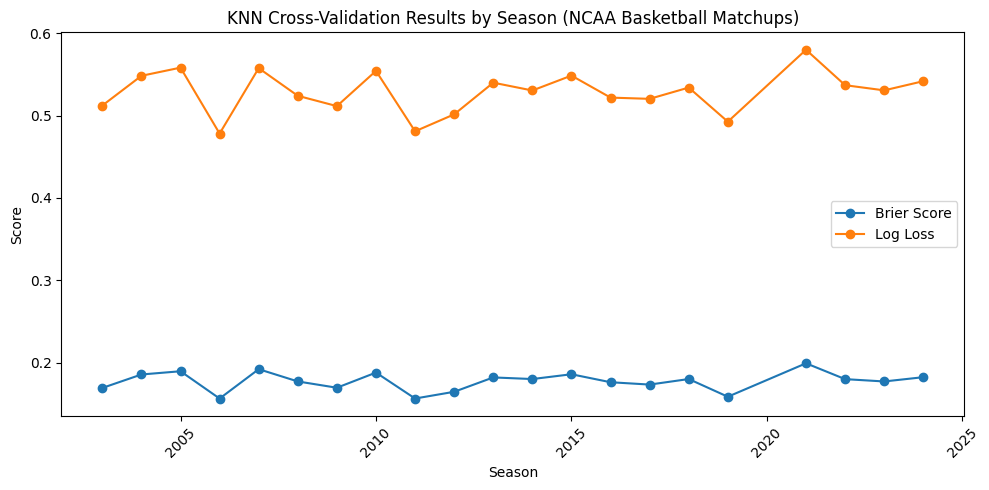

In [12]:
#Plot by season
plt.figure(figsize = (10, 5))
plt.plot(
    df_cv_results['Season'],
    df_cv_results['BrierScore'],
    marker = 'o',
    label = 'Brier Score'
)
plt.plot(
    df_cv_results['Season'],
    df_cv_results['LogLoss'],
    marker = 'o',
    label = 'Log Loss'
)
plt.xlabel("Season")
plt.ylabel("Score")
plt.title("KNN Cross-Validation Results by Season (NCAA Basketball Matchups)")
plt.legend()
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()